# Derivative of Trigonometric Functions

A guided notebook on the **derivatives of sine and cosine**, transcribed and expanded
from the Coursera *Machine Learning Calculus* lecture
*"Derivative of trigonometric functions"*.

This notebook explains:

- the two key results $\;(\sin x)' = \cos x\;$ and $\;(\cos x)' = -\sin x$
- the **slope vs. value** intuition shown in the lecture
- the **geometric proof** using the unit circle
- worked examples
- symbolic checks with SymPy
- numerical derivative checks
- Python visualizations
- practice exercises

This notebook follows the repository `GUIDELINES.md` template.

## 1. Introduction

Trigonometric functions appear everywhere — oscillations, waves, rotations, and
periodic signals. To use them in optimization and machine learning we need to know
how they **change**, i.e. their derivatives.

The whole lecture builds toward two results worth memorizing:

$$
\frac{d}{dx}\sin x = \cos x
\qquad\qquad
\frac{d}{dx}\cos x = -\sin x
$$

After this notebook you will be able to:

- explain *why* these formulas hold, both visually and geometrically
- differentiate combinations of $\sin$ and $\cos$
- verify the results numerically and symbolically in Python

## 2. Intuition: comparing slopes to values

The lecture starts with a simple observation. Take $f(x)=\sin x$ and look at the
**slopes** (the steepness of the tangent) at four convenient points:

| point $x$ | slope of $\sin x$ |
|---|---|
| $-\pi$ | $-1$ |
| $-\tfrac{\pi}{2}$ | $0$ |
| $0$ | $1$ |
| $\tfrac{\pi}{2}$ | $0$ |

Now look at the **values** of $\cos x$ at the *same* points:

| point $x$ | value of $\cos x$ |
|---|---|
| $-\pi$ | $-1$ |
| $-\tfrac{\pi}{2}$ | $0$ |
| $0$ | $1$ |
| $\tfrac{\pi}{2}$ | $0$ |

The slopes of $\sin$ match the values of $\cos$ exactly. As the lecturer asks —
*"Do you think this is a coincidence?"* — it is **not**:

$$
f(x)=\sin x \;\Rightarrow\; f'(x)=\cos x
$$

The same idea, run for $\cos x$, gives slopes that match the values of $-\sin x$:

$$
f(x)=\cos x \;\Rightarrow\; f'(x)=-\sin x
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

# The four sample points from the lecture
points = np.array([-np.pi, -np.pi/2, 0, np.pi/2])
labels = ["-π", "-π/2", "0", "π/2"]

slope_of_sin = np.cos(points)   # tangent slope of sin x  = cos x
value_of_cos = np.cos(points)   # value of cos x

print(f"{'x':>6} | {'slope of sin x':>15} | {'value of cos x':>15}")
print("-" * 44)
for lab, s, v in zip(labels, slope_of_sin, value_of_cos):
    print(f"{lab:>6} | {s:>15.3f} | {v:>15.3f}")

     x |  slope of sin x |  value of cos x
--------------------------------------------
    -π |          -1.000 |          -1.000
  -π/2 |           0.000 |           0.000
     0 |           1.000 |           1.000
   π/2 |           0.000 |           0.000


### Visualizing the slope/value match

Below we plot $\sin x$ together with the tangent lines at the four points. The
steepness of each red tangent equals the height of $\cos x$ at that point.

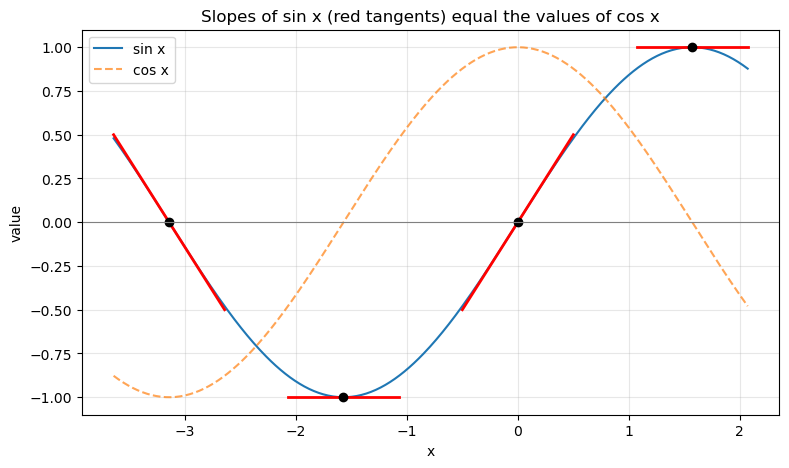

In [2]:
x = np.linspace(-np.pi - 0.5, np.pi/2 + 0.5, 400)

plt.figure(figsize=(9, 5))
plt.plot(x, np.sin(x), label="sin x")
plt.plot(x, np.cos(x), "--", label="cos x", alpha=0.7)

for p, lab in zip(points, labels):
    slope = np.cos(p)                 # derivative of sin at p
    t = np.linspace(p - 0.5, p + 0.5, 10)
    tangent = np.sin(p) + slope * (t - p)
    plt.plot(t, tangent, "r", linewidth=2)
    plt.plot(p, np.sin(p), "ko")

plt.axhline(0, color="gray", linewidth=0.8)
plt.title("Slopes of sin x (red tangents) equal the values of cos x")
plt.xlabel("x")
plt.ylabel("value")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 3. Theory: the two formulas

$$
\boxed{\;(\sin x)' = \cos x\;}
\qquad
\boxed{\;(\cos x)' = -\sin x\;}
$$

A useful way to remember the **sign flip**: differentiating cycles through

$$
\sin x \;\to\; \cos x \;\to\; -\sin x \;\to\; -\cos x \;\to\; \sin x \;\to\;\cdots
$$

so the pattern repeats every four derivatives.

## 4. Geometric proof (unit circle)

The lecture gives a beautiful geometric argument. Take a circle of radius $1$ and a
radial line making angle $x$ with the horizontal axis. Its projections are

$$
\text{horizontal} = \cos x, \qquad \text{vertical} = \sin x .
$$

Now nudge the angle by a small amount $\Delta x$. The tip of the radius moves a tiny
bit, forming a small (orange) right triangle with legs

$$
\text{horizontal leg} = -\Delta\cos x, \qquad \text{vertical leg} = \Delta\sin x,
$$

hypotenuse $h$, and top angle $\varphi$.

From basic right-triangle trigonometry:

$$
\cos\varphi = \frac{\text{adjacent}}{h} = \frac{\Delta\sin x}{h}
\;\Rightarrow\; \Delta\sin x = h\cos\varphi
$$

$$
\sin\varphi = \frac{\text{opposite}}{h} = \frac{-\Delta\cos x}{h}
\;\Rightarrow\; -\Delta\cos x = h\sin\varphi
$$

As $\Delta x \to 0$:

- the hypotenuse $h$ approaches the arc length, which for a unit circle is $\Delta x$;
- the angle $\varphi$ approaches $x$.

Substituting $h \to \Delta x$ and $\varphi \to x$:

$$
\Delta\sin x \to \Delta x \,\cos x
\qquad\qquad
-\Delta\cos x \to \Delta x \,\sin x
$$

Dividing by $\Delta x$ and taking the limit gives the derivatives directly:

$$
\frac{\Delta\sin x}{\Delta x} \to \cos x = (\sin x)'
\qquad\qquad
\frac{\Delta\cos x}{\Delta x} \to -\sin x = (\cos x)'
$$

exactly confirming the intuition built from the slope/value table.

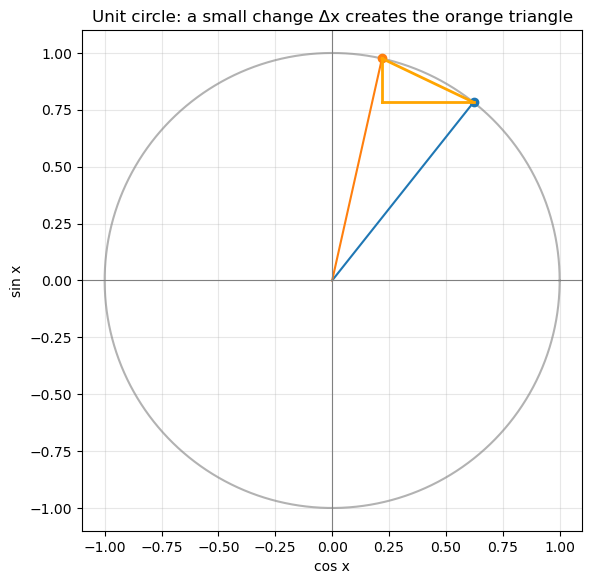

In [3]:
# Illustration of the geometric argument on the unit circle
x0 = 0.9          # base angle
dx = 0.45         # an exaggerated Δx so the small triangle is visible

theta = np.linspace(0, 2*np.pi, 400)
plt.figure(figsize=(6.5, 6.5))
plt.plot(np.cos(theta), np.sin(theta), color="gray", alpha=0.6)

# the two radial lines
for ang, c in [(x0, "C0"), (x0 + dx, "C1")]:
    plt.plot([0, np.cos(ang)], [0, np.sin(ang)], c)
    plt.plot(np.cos(ang), np.sin(ang), c + "o")

# the small (orange) triangle between the two tips
P  = np.array([np.cos(x0),      np.sin(x0)])
Q  = np.array([np.cos(x0 + dx), np.sin(x0 + dx)])
corner = np.array([Q[0], P[1]])
plt.plot([P[0], corner[0]], [P[1], corner[1]], "orange", linewidth=2)
plt.plot([corner[0], Q[0]], [corner[1], Q[1]], "orange", linewidth=2)
plt.plot([P[0], Q[0]],      [P[1], Q[1]],      "orange", linewidth=2)

plt.gca().set_aspect("equal")
plt.axhline(0, color="gray", linewidth=0.8)
plt.axvline(0, color="gray", linewidth=0.8)
plt.title("Unit circle: a small change Δx creates the orange triangle")
plt.xlabel("cos x")
plt.ylabel("sin x")
plt.grid(True, alpha=0.3)
plt.show()

## 5. Worked examples

**Example 1.** $f(x) = \sin x \;\Rightarrow\; f'(x) = \cos x$.

**Example 2.** $f(x) = \cos x \;\Rightarrow\; f'(x) = -\sin x$.

**Example 3 (chain rule).** $f(x) = \sin(3x)$.
With $u = 3x$, $\;f'(x) = \cos(3x)\cdot 3 = 3\cos(3x)$.

**Example 4 (product rule).** $f(x) = x\sin x$.
$\;f'(x) = (1)\sin x + x\cos x = \sin x + x\cos x$.

**Example 5 (second derivative).** $f(x)=\sin x$.
$\;f'(x)=\cos x,\; f''(x) = -\sin x$ — note $f'' = -f$, the signature of oscillation.

## 6. Symbolic checks with SymPy

In [4]:
x = sp.symbols('x')

examples = [
    sp.sin(x),
    sp.cos(x),
    sp.sin(3*x),
    x * sp.sin(x),
]

for expr in examples:
    print("f(x)  =", expr)
    print("f'(x) =", sp.simplify(sp.diff(expr, x)))
    print("-" * 60)

# second derivative of sin x
print("d²/dx² sin x =", sp.diff(sp.sin(x), x, 2))

f(x)  = sin(x)
f'(x) = cos(x)
------------------------------------------------------------
f(x)  = cos(x)


f'(x) = -sin(x)
------------------------------------------------------------
f(x)  = sin(3*x)
f'(x) = 3*cos(3*x)
------------------------------------------------------------
f(x)  = x*sin(x)
f'(x) = x*cos(x) + sin(x)
------------------------------------------------------------
d²/dx² sin x = -sin(x)


## 7. Numerical check

We confirm the formulas with a finite-difference approximation

$$
f'(x) \approx \frac{f(x+h) - f(x-h)}{2h}
$$

and compare against the exact derivatives $\cos x$ and $-\sin x$.

In [5]:
def numerical_derivative(func, x, h=1e-6):
    return (func(x + h) - func(x - h)) / (2 * h)

test_points = np.array([-np.pi, -np.pi/2, 0.0, np.pi/2, 1.0])

print("Check (sin x)' = cos x")
print(f"{'x':>8} | {'numeric':>10} | {'cos x':>10}")
for p in test_points:
    print(f"{p:>8.3f} | {numerical_derivative(np.sin, p):>10.5f} | {np.cos(p):>10.5f}")

print("\nCheck (cos x)' = -sin x")
print(f"{'x':>8} | {'numeric':>10} | {'-sin x':>10}")
for p in test_points:
    print(f"{p:>8.3f} | {numerical_derivative(np.cos, p):>10.5f} | {-np.sin(p):>10.5f}")

Check (sin x)' = cos x
       x |    numeric |      cos x
  -3.142 |   -1.00000 |   -1.00000
  -1.571 |    0.00000 |    0.00000
   0.000 |    1.00000 |    1.00000
   1.571 |    0.00000 |    0.00000
   1.000 |    0.54030 |    0.54030

Check (cos x)' = -sin x
       x |    numeric |     -sin x
  -3.142 |    0.00000 |    0.00000
  -1.571 |    1.00000 |    1.00000
   0.000 |    0.00000 |   -0.00000
   1.571 |   -1.00000 |   -1.00000
   1.000 |   -0.84147 |   -0.84147


## 8. Visualizing the functions and their derivatives

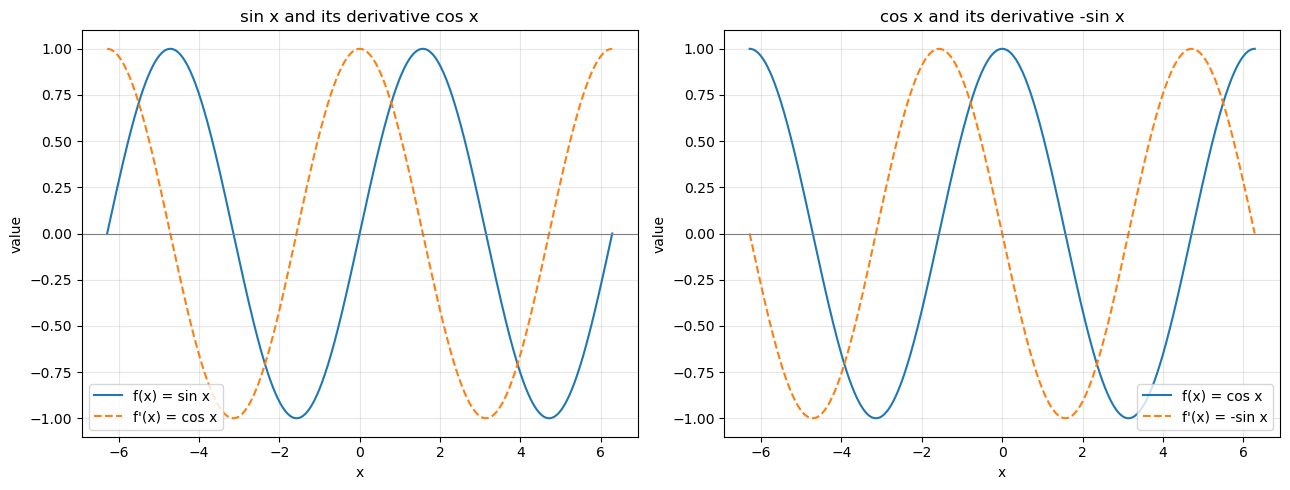

In [6]:
x = np.linspace(-2*np.pi, 2*np.pi, 800)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(x, np.sin(x), label="f(x) = sin x")
axes[0].plot(x, np.cos(x), "--", label="f'(x) = cos x")
axes[0].set_title("sin x and its derivative cos x")

axes[1].plot(x, np.cos(x), label="f(x) = cos x")
axes[1].plot(x, -np.sin(x), "--", label="f'(x) = -sin x")
axes[1].set_title("cos x and its derivative -sin x")

for ax in axes:
    ax.axhline(0, color="gray", linewidth=0.8)
    ax.set_xlabel("x")
    ax.set_ylabel("value")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

## 9. Exercises

### Basic
1. State the derivatives of $\sin x$ and $\cos x$ from memory.
2. Differentiate $f(x) = \cos x + \sin x$.

### Intermediate
3. Differentiate $f(x) = \sin(5x)$ using the chain rule.
4. Differentiate $f(x) = x^2 \cos x$ using the product rule.

### Advanced
5. Show that $f(x) = \sin x$ satisfies $f''(x) = -f(x)$, and explain what this says
   about oscillating systems.
6. Using the derivative cycle $\sin \to \cos \to -\sin \to -\cos$, find the
   $100^{\text{th}}$ derivative of $\sin x$.

## 10. Solutions / Checks

In [7]:
x = sp.symbols('x')

# 2.
print("2.", sp.diff(sp.cos(x) + sp.sin(x), x))            # -sin x + cos x
# 3.
print("3.", sp.diff(sp.sin(5*x), x))                      # 5*cos(5x)
# 4.
print("4.", sp.expand(sp.diff(x**2 * sp.cos(x), x)))      # 2x cos x - x^2 sin x
# 5.
f = sp.sin(x)
print("5. f'' =", sp.diff(f, x, 2), "  ->  f'' + f =", sp.simplify(sp.diff(f, x, 2) + f))
# 6. 100th derivative: 100 mod 4 == 0  ->  back to sin x
print("6. 100th derivative of sin x =", sp.diff(sp.sin(x), x, 100))

2. -sin(x) + cos(x)
3. 5*cos(5*x)
4. -x**2*sin(x) + 2*x*cos(x)
5. f'' = -sin(x)   ->  f'' + f = 0
6. 100th derivative of sin x = sin(x)


## 11. Conclusion

- The **slopes** of $\sin x$ reproduce the **values** of $\cos x$ — not a coincidence.
- The unit-circle argument turns a small angle change $\Delta x$ into a tiny right
  triangle whose sides, in the limit, yield the derivatives directly.
- The two results to remember:

$$
(\sin x)' = \cos x \qquad (\cos x)' = -\sin x
$$

- Differentiation cycles with period 4:
  $\sin \to \cos \to -\sin \to -\cos \to \sin$.

These derivatives are the building blocks for differentiating any expression
involving trigonometric functions, and combine with the chain, product, and
quotient rules.

## Appendix — Source transcript

This notebook was transcribed from `coursera/videos/trigonomeric_functions.mp4`
(Coursera, *Machine Learning Calculus*, lecture *Derivative of trigonometric
functions*) using OpenAI Whisper (`small.en`). Lightly cleaned, the spoken text was:

> So let's take a look at another family of functions, the trigonometric ones... [the
> lecturer compares the slopes of $\sin x$ at $-\pi, -\tfrac{\pi}{2}, 0, \tfrac{\pi}{2}$
> with the values of $\cos x$ at the same points, notes they coincide, and concludes
> $(\sin x)'=\cos x$; the same argument for $\cos x$ gives $(\cos x)'=-\sin x$. A
> unit-circle picture with a small angle change $\Delta x$ and the resulting orange
> right triangle then proves both results geometrically.]